In [ ]:
import os
os.environ.setdefault('MKL_THREADING_LAYER', 'SEQUENTIAL')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import datetime
import string
from IPython.display import display
torch.set_num_threads(4)

In [36]:
plt.rcParams['font.family']='Arial'

plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12) 
set_dpi=600

In [2]:
device = torch.device("cpu")

In [3]:
data = pd.read_excel("../data/Final_heat_region.xlsx")

In [4]:
data = data.dropna().copy()
data['date'] = pd.to_datetime(data['date'])
data.reset_index(drop=True, inplace=True)
if data.duplicated(['region', 'date']).any():
    raise ValueError('Duplicate region-date rows.')
if not data['date'].dt.year.eq(data['year']).all():
    raise ValueError('Year values do not match dates.')
data.head()

,date,case,region,tavg,tmax,rhum,tw,wbgt,year,month,...,agri_area2,agri_pop,simple_job_pop,pop_density,sex_rate,phase,elder_rate,metro,agri_area,rate_agri_pop
0,2016-05-23,0.0,Gangwon,19.223077,26.446154,59.176923,20.677097,23.832554,2016,5,...,66567,171363,226000,0.001481,101.578826,0,9.0,0,104330,0.110712
1,2016-05-24,0.0,Gangwon,17.153846,21.200000,78.423077,18.480108,19.984827,2016,5,...,66567,171363,226000,0.001481,101.578826,0,9.0,0,104330,0.110712
2,2016-05-25,0.0,Gangwon,19.223077,24.961538,60.307692,19.513112,22.448505,2016,5,...,66567,171363,226000,0.001481,101.578826,0,9.0,0,104330,0.110712
3,2016-05-26,0.0,Gangwon,19.323077,23.576923,70.184615,19.637464,21.809240,2016,5,...,66567,171363,226000,0.001481,101.578826,0,9.0,0,104330,0.110712
4,2016-05-27,0.0,Gangwon,19.661538,25.776923,61.515385,20.426137,23.355032,2016,5,...,66567,171363,226000,0.001481,101.578826,0,9.0,0,104330,0.110712


In [5]:
Region = data['region'].unique()
Region

array(['Gangwon', 'Gyeonggi', 'Gyeongnam', 'Gyeongbuk', 'Gwangju',
       'Daegu', 'Daejeon', 'Busan', 'Seoul', 'Ulsan', 'Incheon',
       'Jeonnam', 'Jeonbuk', 'Jeju', 'Chungnam', 'Chungbuk'], dtype=object)

In [6]:
model_weights = {
    'LR':   {'alpha': 0.3, 'beta': 0.1},
    'RF':   {'alpha': 0.4, 'beta': 0.2},
    'XGB':  {'alpha': 0.9, 'beta': 0.1},
    'LSTM': {'alpha': 1.0, 'beta': 0.1},
}

data['COVID19'] = 0
data.loc[(data['year'] >= 2020) & (data['year'] <= 2021), 'COVID19'] = 1

In [ ]:
train_years = list(range(2016, 2021))
valid_years = [2021]
test_years = [2022, 2023]
split_years = {'train': train_years, 'valid': valid_years, 'test': test_years}
all_years = [year for years in split_years.values() for year in years]
if len(all_years) != len(set(all_years)):
    raise ValueError('Train, validation, and test periods overlap.')

In [8]:
def make_dataset(x_data, y_data, window_size):
    x_list = []
    y_list = []
    for i in range(len(x_data) - window_size+1):
        x_list.append(np.array(x_data.iloc[i:i+window_size]))
        y_list.append(np.array(y_data.iloc[i+window_size-1]))
    x_list = np.array(x_list)
    y_list = np.array(y_list).reshape(-1)
    return x_list, y_list

In [9]:
window_size = 3

target = 'case'

features = ['tmax', 'tavg', 'rhum', 'weight_wbgt','wbgt', 'metro','sex_rate', 'elder_rate', 'COVID19','month', 're_wbgt', 're_rate', 'phase', 'cons', 'pop', '60+', 'agri_area','pop_density']

In [10]:
display(pd.DataFrame([
    {'period': period, 'years': ', '.join(map(str, years))}
    for period, years in split_years.items()
]))
print('COVID19 = 1 for 2020-2021; scaling uses training years only.')

,period,years
0,train,"2016, 2017, 2018, 2019, 2020"
1,valid,2021
2,test,"2022, 2023"


COVID19 = 1 for 2020-2021; scaling uses training years only.


In [13]:
data_load = '../models/'
checkpoint = torch.load(data_load + 'LSTM_model.pth', map_location='cpu', weights_only=True)
best_params = checkpoint['best_params']
if list(checkpoint['features']) != features or int(checkpoint['window_size']) != window_size:
    raise ValueError('LSTM feature order/window differs from this notebook.')
control = checkpoint.get('training_control', {})
if sorted(control.get('train_years', [])) != train_years:
    raise ValueError('LSTM checkpoint was trained with different years.')
if sorted(control.get('validation_years', [])) != valid_years:
    raise ValueError('LSTM checkpoint used different validation years.')
model_weights['LSTM'] = {'alpha': float(best_params['alpha']), 'beta': float(best_params['beta'])}
print('Saved LSTM training seed:', checkpoint.get('seed', best_params.get('seed')))

Saved LSTM training seed: 10


In [14]:
def build_model_inputs(base_data, alpha, beta, saved_scaling=None):
    """Create chronological, separate train/validation/test inputs for a saved model."""
    model_data = base_data.loc[base_data['year'].isin(all_years)].copy()
    model_data['weight_wbgt'] = (model_data['wbgt']
        + alpha * model_data['wbgt_1_day_ago']
        + beta * model_data['wbgt_2_day_ago'])
    model_data['COVID19'] = model_data['year'].between(2020, 2021).astype(int)

    scaling_rows = model_data.loc[model_data['year'].isin(train_years), features]
    feature_min = scaling_rows.min()
    feature_range = (scaling_rows.max() - feature_min).replace(0, 1)
    if saved_scaling is not None:
        saved_min = pd.Series(saved_scaling['feature_min'], dtype=float).reindex(features)
        saved_range = pd.Series(saved_scaling['feature_range'], dtype=float).reindex(features)
        if not (np.allclose(feature_min, saved_min, rtol=1e-6, atol=1e-8)
                and np.allclose(feature_range, saved_range, rtol=1e-6, atol=1e-8)):
            raise ValueError('Training-data scaling differs from the LSTM checkpoint. Check data version.')
        feature_min, feature_range = saved_min, saved_range
    if (not np.isfinite(feature_min).all() or not np.isfinite(feature_range).all()
            or (feature_range <= 0).any()):
        raise ValueError('Invalid scaling values.')
    scaled = (model_data[features] - feature_min) / feature_range
    if not np.isfinite(scaled.to_numpy()).all():
        raise ValueError('Inputs contain non-finite values.')

    x_blocks, y_blocks, rows = [], [], []
    for region in Region:
        for year in sorted(all_years):
            group = model_data.loc[
                model_data['region'].eq(region) & model_data['year'].eq(year)
            ].sort_values('date')
            if len(group) < window_size:
                raise ValueError(f'Not enough observations: {region}, {year}')
            x_window, y_window = make_dataset(scaled.loc[group.index], group[target], window_size)
            x_blocks.append(x_window)
            y_blocks.append(y_window)
            rows.append(group.iloc[window_size - 1:][['region', 'year', 'date']])
    x_all = np.concatenate(x_blocks).astype(np.float32)
    y_all = np.concatenate(y_blocks).astype(np.float32)
    info = pd.concat(rows, ignore_index=True)
    result = {'feature_min': feature_min, 'feature_range': feature_range}
    for period, years in split_years.items():
        mask = info['year'].isin(years).to_numpy()
        x = x_all[mask]
        period_info = info.loc[mask].reset_index(drop=True)
        counts = period_info.groupby('region').size().reindex(Region)
        if counts.isna().any() or counts.nunique() != 1:
            raise ValueError(f'Regions have different sequence counts in {period}.')
        result[f'X_{period}_ml'] = x.reshape(len(x), -1)
        result[f'X_{period}_lstm'] = torch.from_numpy(x)
        result[f'y_{period}'] = y_all[mask]
        result[f'info_{period}'] = period_info
        result[f'{period}_num'] = int(counts.iloc[0])
    return result

In [15]:
model_inputs = {}
for model_name, weights in model_weights.items():
    model_inputs[model_name] = build_model_inputs(
        data, alpha=weights['alpha'], beta=weights['beta'],
        saved_scaling=checkpoint if model_name == 'LSTM' else None
    )

for period in split_years:
    reference = model_inputs['LR']
    globals()[f'y_{period}_total'] = reference[f'y_{period}']
    for name, inputs in model_inputs.items():
        if not np.array_equal(reference[f'y_{period}'], inputs[f'y_{period}']):
            raise ValueError(f'{name}: {period} targets differ.')
        if not reference[f'info_{period}'].equals(inputs[f'info_{period}']):
            raise ValueError(f'{name}: {period} region/date keys differ.')
    for name in ['LR', 'RF', 'XGB']:
        globals()[f'X_{period}_total_{name.lower()}'] = model_inputs[name][f'X_{period}_ml']
    globals()[f'X_{period}_total_L'] = model_inputs['LSTM'][f'X_{period}_lstm']

train_num = model_inputs['LR']['train_num']
valid_num = model_inputs['LR']['valid_num']
test_num = model_inputs['LR']['test_num']
display(pd.DataFrame([
    {'period': period, 'years': ', '.join(map(str, years)),
     'sequences_per_region': model_inputs['LR'][f'{period}_num'],
     'total_sequences': len(model_inputs['LR'][f'y_{period}'])}
    for period, years in split_years.items()
]))

,period,years,sequences_per_region,total_sequences
0,train,"2016, 2017, 2018, 2019, 2020",570,9120
1,valid,2021,132,2112
2,test,"2022, 2023",264,4224


In [16]:
class LSTM(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=2,dropout=0.2):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=len(features),
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc1 = nn.Linear(hidden_dim, hidden_dim//2)
        self.fc2 = nn.Linear(hidden_dim//2, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.shape[0], self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers, x.shape[0], self.hidden_dim, device=x.device)
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = F.softplus(x)

        return x

In [17]:
for model_name in ['LR', 'RF', 'XGB']:
    if model_name == 'XGB':
        model = XGBRegressor()
        model.load_model(data_load + model_name + '_model.json')
    else:
        model = joblib.load(data_load + model_name + '_model.pkl')
    globals()[f'{model_name}_model'] = model
    for period in split_years:
        prediction = model.predict(model_inputs[model_name][f'X_{period}_ml']).reshape(-1)
        if model_name == 'LR':
            prediction = np.maximum(0, prediction)
        globals()[f'{model_name}_pred_{period}'] = prediction

c:\Python\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Python\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Python\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use

In [18]:
LSTM_model = LSTM(
    hidden_dim=int(best_params['hidden_dim']),
    num_layers=int(best_params['num_layers']),
    dropout=float(best_params['dropout'])
).to(device)
LSTM_model.load_state_dict(checkpoint['model_state_dict'], strict=True)
LSTM_model.eval()
with torch.inference_mode():
    for period in split_years:
        inputs = model_inputs['LSTM'][f'X_{period}_lstm']
        blocks = [LSTM_model(inputs[start:start + 512].to(device)).cpu()
                  for start in range(0, len(inputs), 512)]
        globals()[f'LSTM_pred_{period}'] = torch.cat(blocks, dim=0)

In [19]:
machine_values = ['LR','RF','XGB','LSTM']

In [20]:
def regression_metrics(observed, predicted):
    if torch.is_tensor(predicted):
        predicted = predicted.detach().cpu().numpy()
    observed = np.asarray(observed, dtype=np.float64).reshape(-1)
    predicted = np.asarray(predicted, dtype=np.float64).reshape(-1)
    if len(observed) != len(predicted) or not np.isfinite(predicted).all():
        raise ValueError('Invalid predictions.')
    mse = mean_squared_error(observed, predicted)
    return {'MSE': mse, 'RMSE': np.sqrt(mse),
            'MAE': np.mean(np.abs(observed - predicted)), 'R2': r2_score(observed, predicted)}

In [21]:
prediction_frames = {}
for model_name in machine_values:
    for period in split_years:
        frame = model_inputs[model_name][f'info_{period}'].copy()
        prediction = globals()[f'{model_name}_pred_{period}']
        if torch.is_tensor(prediction):
            prediction = prediction.detach().cpu().numpy()
        frame['observed'] = model_inputs[model_name][f'y_{period}']
        frame['predicted'] = np.asarray(prediction).reshape(-1)
        prediction_frames[(model_name, period)] = frame

In [22]:
for period in split_years:
    records = []
    for name in machine_values:
        frame = prediction_frames[(name, period)]
        records.append({'Estimator': name, **regression_metrics(frame['observed'], frame['predicted'])})
    globals()[f'{period}_Result_ACC'] = pd.DataFrame(records)

In [23]:
print('Training: 2016-2020')
display(train_Result_ACC)
print('Validation: 2021')
display(valid_Result_ACC)

Training: 2016-2020


,Estimator,MSE,RMSE,MAE,R2
0,LR,6.973712,2.640779,1.133175,0.402564
1,RF,1.859286,1.363556,0.557118,0.840715
2,XGB,2.362181,1.536939,0.801425,0.797633
3,LSTM,2.386612,1.544866,0.751640,0.795540


Validation: 2021


,Estimator,MSE,RMSE,MAE,R2
0,LR,1.553866,1.246542,0.653736,0.406994
1,RF,0.494020,0.702866,0.353438,0.811466
2,XGB,0.757376,0.870274,0.576355,0.710961
3,LSTM,0.926575,0.962587,0.485858,0.646389


In [24]:
print('Test: 2022-2023')
display(test_Result_ACC)

Test: 2022-2023


,Estimator,MSE,RMSE,MAE,R2
0,LR,4.048717,2.012142,0.931755,0.409246
1,RF,3.146097,1.773724,0.770520,0.540948
2,XGB,3.688196,1.920468,0.875882,0.461850
3,LSTM,2.660449,1.631088,0.774899,0.611810


In [25]:
region_records = []
for name in machine_values:
    for period in split_years:
        for region, frame in prediction_frames[(name, period)].groupby('region', sort=False):
            region_records.append({'Region': region, 'Estimator': name, 'period': period,
                                  **regression_metrics(frame['observed'], frame['predicted'])})
regional_metrics = pd.DataFrame(region_records)

In [26]:
print(f'Rows per region: train={train_num}, validation={valid_num}, test={test_num}')

Rows per region: train=570, validation=132, test=264


In [27]:
Result_ACC_region = regional_metrics.loc[ regional_metrics['Region'].isin(['Chungnam', 'Jeonnam', 'Gyeongbuk'])].reset_index(drop=True)

In [28]:
Result_ACC_region

,Region,Estimator,period,MSE,RMSE,MAE,R2
0,Gyeongbuk,LR,train,3.251723,1.803253,1.150355,0.616772
1,Jeonnam,LR,train,4.796619,2.190119,1.297084,0.550582
2,Chungnam,LR,train,3.268945,1.808022,0.991588,0.577739
3,Gyeongbuk,LR,valid,1.064092,1.031548,0.630113,0.677485
4,Jeonnam,LR,valid,0.865138,0.930128,0.631657,0.486365
5,Chungnam,LR,valid,0.991198,0.995589,0.558344,0.496233
6,Gyeongbuk,LR,test,3.800706,1.949540,1.164197,0.469081
7,Jeonnam,LR,test,2.638958,1.624487,1.028505,0.539999
8,Chungnam,LR,test,3.499198,1.870614,1.043347,0.544462
9,Gyeongbuk,RF,train,1.090535,1.044287,0.600438,0.871476


In [29]:
national_frames = {}
for period in split_years:
    for name in machine_values:
        frame = prediction_frames[(name, period)]
        if not frame.groupby('date')['region'].nunique().eq(len(Region)).all():
            raise ValueError(f'Incomplete regional coverage: {name}, {period}')
        national = frame.groupby('date', as_index=False)[['observed', 'predicted']].sum().sort_values('date')
        national_frames[(name, period)] = national
        globals()[f'total_{name}_pred_{period}'] = national['predicted'].to_numpy()
    globals()[f'total_y_{period}'] = national_frames[('LR', period)]['observed'].to_numpy()

In [30]:
# Dates for all test plots come from the actual target observations.
test_dates = national_frames[('LR', 'test')]['date'].reset_index(drop=True)

In [31]:
national_metric_records = []

In [32]:
for name in machine_values:
    row = {'Estimator': name}
    for period in split_years:
        frame = national_frames[(name, period)]
        for metric, value in regression_metrics(frame['observed'], frame['predicted']).items():
            row[f'{period}_{metric}'] = value
    national_metric_records.append(row)
Result_ACC_total = pd.DataFrame(national_metric_records)

In [33]:
labels=['LR','RF','XGB','LSTM']

In [34]:
Region_code=['G1','G2','G3','G4','G5','G6','G7','G8','G9','G10','G11','G12','G13','G14','G15','G16']

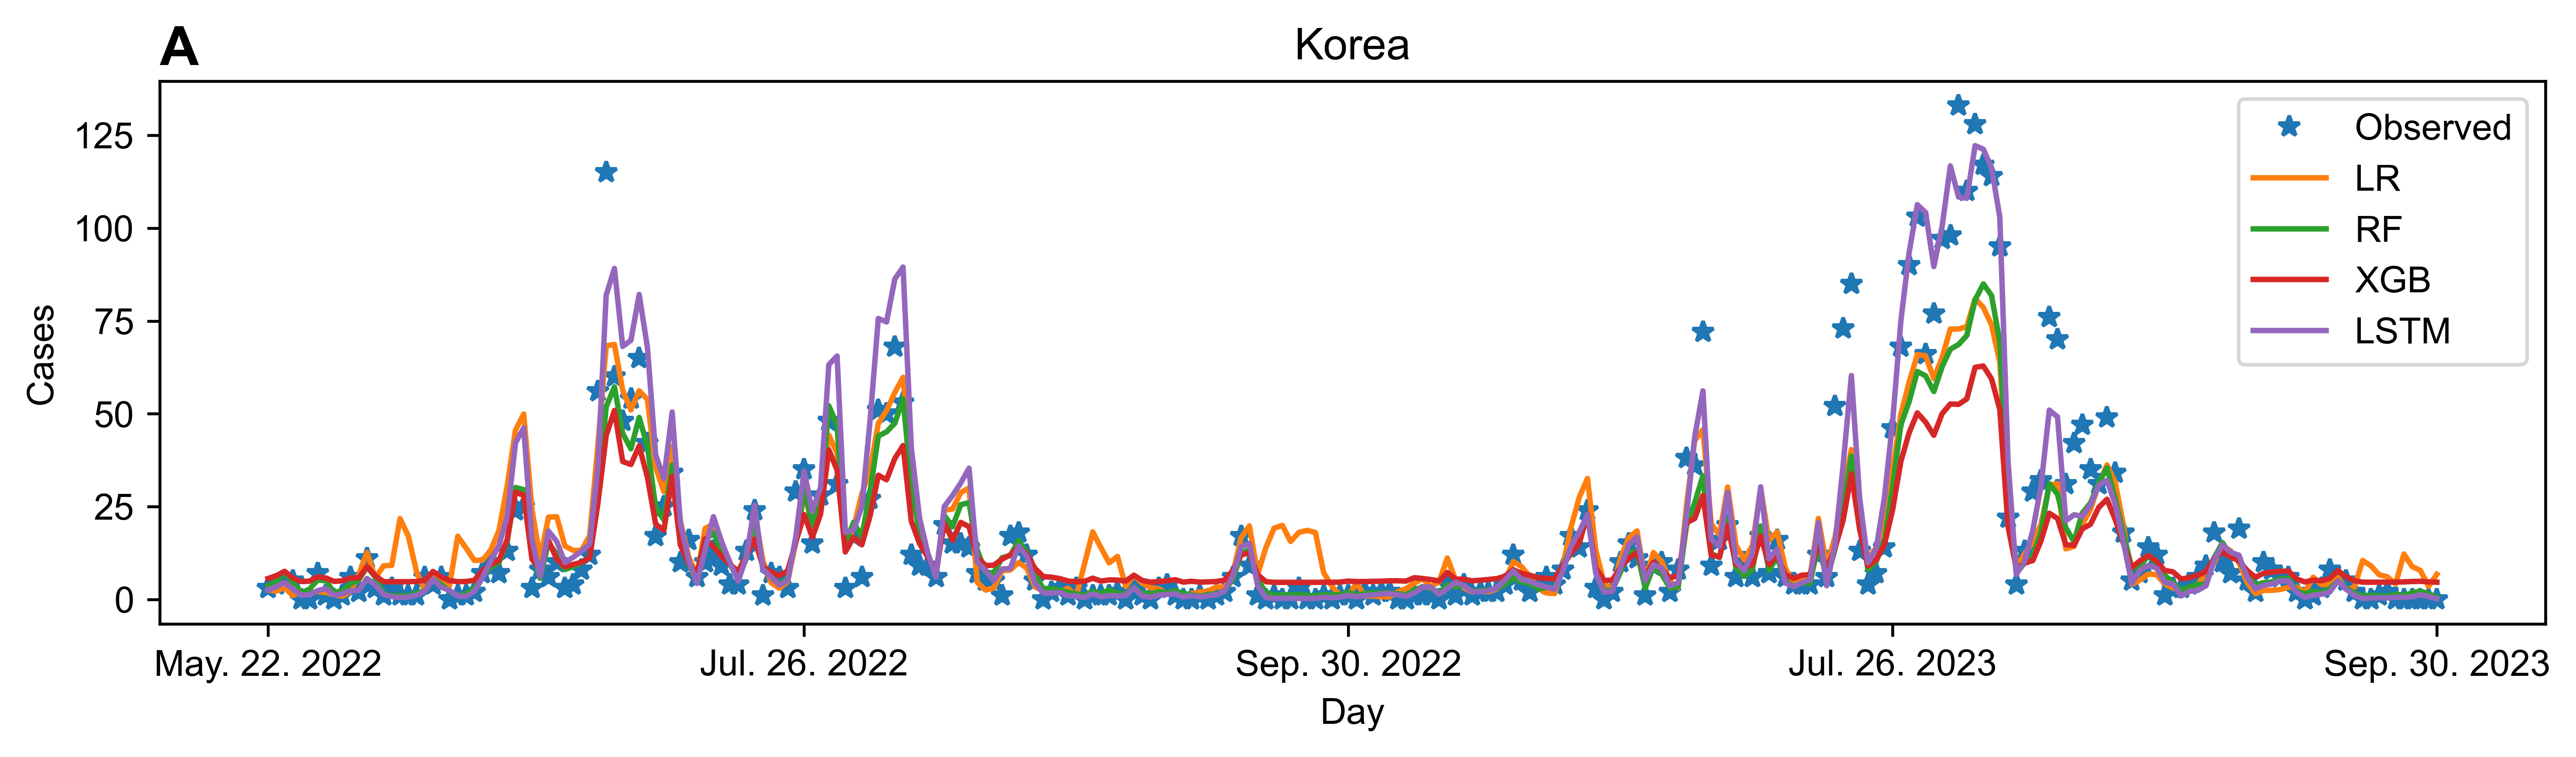

In [ ]:
with torch.no_grad():
    fig, ax = plt.subplots(1,1, figsize=(10, 3),dpi=set_dpi)
    
    start1 = datetime.datetime(2022, 5, 22)
    start2 = datetime.datetime(2023, 5, 22)
    x = range(len(total_y_test))
    ax.plot(x, total_y_test,'*',label='Observed')
    tick_positions = np.unique(np.linspace(0, len(test_dates)-1, 5, dtype=int)).tolist()
    tick_labels = test_dates.iloc[tick_positions].dt.strftime('%b. %d. %Y').tolist()

    for s,k in enumerate(machine_values):
        ax.plot(x, np.array(globals()['total_{}_pred_test'.format(k)]),label=labels[s])
    ax.set_title('Korea')
    ax.set_xlabel('Day')
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel('Cases')
    ax.legend(loc="best")
    ax.text(0,1.03,'{}'.format(string.ascii_uppercase[0]),transform=ax.transAxes,weight='bold',fontsize=15)

    plt.tight_layout()
    plt.show()

    fig.savefig('../figure/Model_comparison_national.jpg', format='jpg', bbox_inches='tight', pad_inches=.1, dpi=set_dpi)

In [43]:
with torch.no_grad():
    fig, ax = plt.subplots(8, 2, figsize=(12, 20), dpi=set_dpi)
    ax = ax.flatten()

    Region_order = [8,1,10,15,14,6,12,11,4,13,0,3,5,2,9,7]
    tick_positions = np.unique(np.linspace(0, len(test_dates)-1, 5, dtype=int)).tolist()
    tick_labels = test_dates.iloc[tick_positions].dt.strftime('%b. %d. %Y').tolist()

    for plot_idx, region_idx in enumerate(Region_order):
        region_name = Region[region_idx]
        region_code = Region_code[plot_idx]
        temp = y_test_total[test_num*region_idx : test_num*(region_idx+1)]
        temp_x = range(len(temp))
        
        ax[plot_idx].plot(temp_x, temp, '*', label='Observed')
        
        for s, k in enumerate(machine_values):
            pred = np.array(globals()['{}_pred_test'.format(k)])
            ax[plot_idx].plot(temp_x, pred[test_num*region_idx : test_num*(region_idx+1)], label=labels[s])
        
        ax[plot_idx].set_title(f'{region_name} ({region_code})', weight='bold')
        ax[plot_idx].set_xlabel('Day')
        ax[plot_idx].set_xticks(tick_positions)
        ax[plot_idx].set_xticklabels(tick_labels)
        ax[plot_idx].set_ylabel('Cases')

        if (plot_idx == 0) | (plot_idx == 8):
            ax[plot_idx].legend(loc="upper left")
        ax[plot_idx].text(0, 1.03, '{}'.format(string.ascii_uppercase[plot_idx]),
                          transform=ax[plot_idx].transAxes, weight='bold', fontsize=15)

    plt.tight_layout()
    plt.show()

    fig.savefig('../figure/Model_comparison_regional.jpg', format='jpg', bbox_inches='tight', pad_inches=.1, dpi=set_dpi)